<a href="https://colab.research.google.com/github/anyuanay/INFO213/blob/main/INFO213_Week4_logisticRegression_answers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# INFO 213: Data Science Programming 2
___

### Week 4: Introduction to Logistic Regression and Scikit-Learn Library
___


**Agenda:**

- Introduction to logistic regression.
- Introduction to the scikit-learn machine learning library

In [1]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt

# Logistic Regression
We will now take a look at another simple, yet more powerful, algorithm for linear and binary classification problems: logistic regression
- In spite of its name, logistic regression is a model for classification, not regression.
- It is one of the most widely used algorithms for classification in industry.
- It is a fundamental building block of neural networks.

## Logistic Sigmoid Function
- To explain the idea behind logistic regression as a probabilistic model for classification, let's first introduce the logistic sigmoid function, or simply, sigmoid function:
\begin{equation}
\sigma(z) = \frac{1}{1+e^{-z}}
\end{equation}

- The sigmoid function transforms any real number to a value between 0 and 1 as demonstrated in the following program:

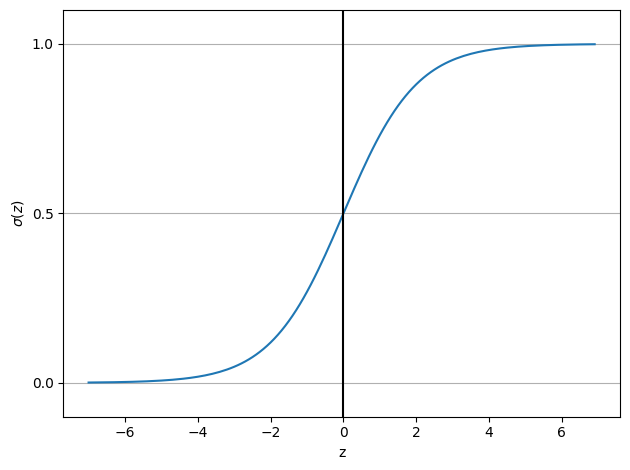

In [2]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

z = np.arange(-7, 7, 0.1)
phi_z = sigmoid(z)

plt.plot(z, phi_z)
plt.axvline(0.0, color='k')
plt.ylim(-0.1, 1.1)
plt.xlabel('z')
plt.ylabel('$\\sigma (z)$')

# y axis ticks and gridline
plt.yticks([0.0, 0.5, 1.0])
ax = plt.gca()
ax.yaxis.grid(True)

plt.tight_layout()
#plt.savefig('images/03_02.png', dpi=300)
plt.show()

## Logistic Regression Uses Sigmoid Function as the Activation Function
- In Adaline, we used the identity function, $\phi(z)$, as the activation function.
- In logistic regression, this activation function simply becomes the sigmoid function.
<img src="https://github.com/rasbt/machine-learning-book/blob/main/ch03/figures/03_03.png?raw=true" width=800>

## Logistic Regression and Conditional Probability
- The output of the sigmoid function is then interpreted as the probability of a particular example belonging to class 1, $Pr(y=1|\mathbf{x}, \mathbf{w})$, given its features, $\mathbf{x}$, parameterized by the weights, $\mathbf{w}$.
- Specifically,
\begin{equation}
\sigma(z) = Pr(y=1|\mathbf{x}, \mathbf{w}) = \frac{1}{1+e^{-z}}
\end{equation}
 - where, $z=w_0x_0+w_1x_1+...+w_mx_m = \mathbf{w}^T\mathbf{x}$
- The predicted probability can then simply be converted into a binary outcome via a threshold function:
\begin{equation}
    \hat{y}=
\begin{cases}
    1,& \text{if } \sigma(z)\geq 0.5\\
    0,              & \text{otherwise}
\end{cases}
\end{equation}
- If we look at the preceding plot of the sigmoid function, this is equivalent to the following:
\begin{equation}
    \hat{y}=
\begin{cases}
    1,& \text{if }  z\geq 0\\
    0,              & \text{otherwise}
\end{cases}
\end{equation}

## Define the Cost Function for Logistic Regression
- In logistic regression, the cross-entropy (or log loss) cost function is commonly used to measure the difference between the predicted probability and the actual class label of a binary classification problem.
- For a single training example with a true label $y$ (where
$y$ is either 0 or 1) and a predicted probability $\sigma(z)$ (the output of the logistic regression model), the cross-entropy loss is given by:
\begin{equation}
cross\_entropy\_loss=-y log(\sigma(z))-(1-y)log(1-\sigma(z)).
\end{equation}
 - When $y=1$, the loss becomes $-log(\sigma(z))$. This term penalizes the model more when the predicted probability is closer to 0 (indicating a higher error).
 - When $y=0$, the loss becomes $-log(1-\sigma(z))$. This term penalizes the model more when the predicted probability is closer to 1 (indicating a higher error).
- Let us plot the function $-log(x)$:


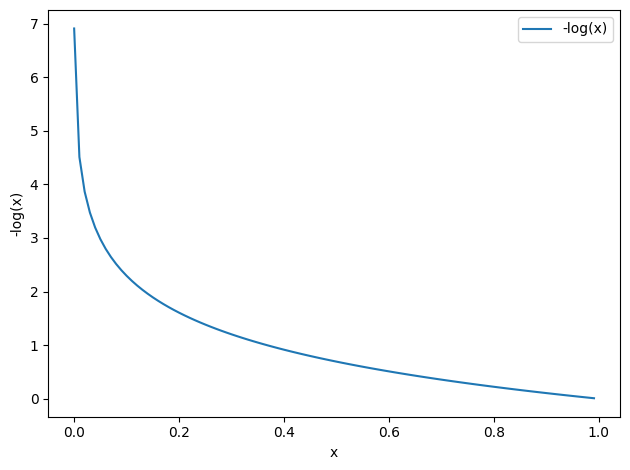

In [3]:
def loss(x):
    return - np.log(x)


x = np.arange(0.001, 1, 0.01)
loss_x = loss(x)

plt.plot(x, loss_x, label='-log(x)')

plt.xlabel('x')
plt.ylabel('-log(x)')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

- For the entire training data with $m$ examples, the cross-entropy loss function is defined as:
\begin{equation}
J(\mathbf{w}) = -\Sigma_i(y^{(i)} log(\sigma(z^{(i)}))+(1-y^{(i)}) log(1-\sigma(z^{(i)})))
\end{equation}

## Derive the Cost Function from the Likelihood Function
- Assume the the individual examples in the dataset are independent. The likelihood, $L$, that we want to maximize when we build a logistic regression model is:
\begin{equation}
 L(\mathbf{w}) = Pr(\mathbf{y}|\mathbf{x}, \mathbf{w})=\Pi_i (y^{(i)}|x^{(i)}, \mathbf{w}) = \Pi_i (\sigma(z^{(i)})^{y^{(i)}}\times (1-\sigma(z^{(i)})^{1-{y}^{(i)}})
\end{equation} where $\sigma(z^{(i)}) = Pr(y^{(i)}=1|x^{(i)}, \mathbf{w})$.
- In practice, it is easier to maximize the (natural) log of this equation, which is called the log-likelihood function:
\begin{equation}
 l(\mathbf{w}) = log(L(\mathbf{w})) = \Sigma_i(y^{(i)}log(\sigma(z^{(i)}))+ (1-{y}^{(i)})log(1-(\sigma(z^{(i)})))
\end{equation}
- The cross-entropy loss function is the negative of the log-likelihood: $J(\mathbf{w}) = - l(\mathbf{w})$. The loss can be visualized as:

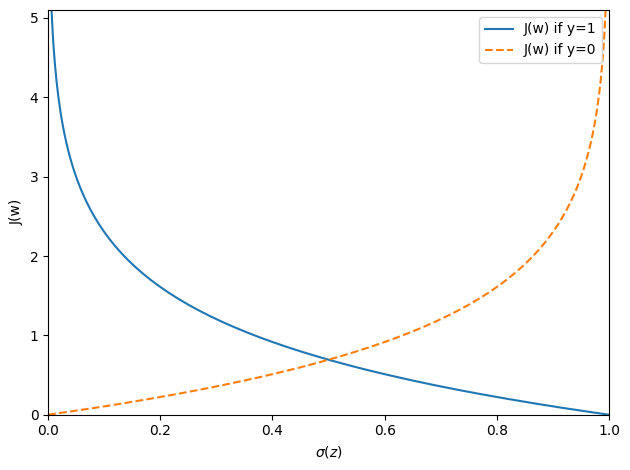

In [4]:
def cost_1(z):
    return - np.log(sigmoid(z))


def cost_0(z):
    return - np.log(1 - sigmoid(z))

z = np.arange(-10, 10, 0.1)
phi_z = sigmoid(z)

c1 = [cost_1(x) for x in z]
plt.plot(phi_z, c1, label='J(w) if y=1')

c0 = [cost_0(x) for x in z]
plt.plot(phi_z, c0, linestyle='--', label='J(w) if y=0')

plt.ylim(0.0, 5.1)
plt.xlim([0, 1])
plt.xlabel(r'$\sigma(z)$')
plt.ylabel('J(w)')
plt.legend(loc='best')
plt.tight_layout()
#plt.savefig('images/03_04.png', dpi=300)
plt.show()

## Update the weights by gradient descent (The same as in Adaline learning):
- Update the weights by taking a step in the opposite direction of the gradient, $\nabla J(\mathbf{w})$ of our cost function $J(\mathbf{w})$:
 - $\mathbf{w} := \mathbf{w} + \Delta \mathbf{w}$, where $\Delta \mathbf{w}= - \eta \nabla J(\mathbf{w})$.
- To compute the gradient of the cost function, we need to compute the partial derivative of the cost function with respect to each weight, $w_j$:
\begin{equation}
\frac{\partial J}{\partial w_j} = - \Sigma_i(y^{(i)}-\sigma(z^{(i)}))x_j^{(i)}
\end{equation}
- Let us derive the above partial derivative. (In the following picture, The symbol $L$ is the cost function symbol $J$ above.)

First,

\begin{equation}
J(\mathbf{w}) = -\Sigma_i(y^{(i)} log(\sigma(z^{(i)}))+(1-y^{(i)}) log(1-\sigma(z^{(i)})))
\end{equation}

Then,

![](https://github.com/rasbt/machine-learning-book/blob/main/ch03/figures/03_25.png?raw=true)

- Each $w_j$ is updated:
\begin{equation}
\Delta w_j = - \eta \frac{\partial J}{\partial w_j} = \eta \Sigma_i(y^{(i)}-\sigma(z^{(i)}))x_j^{(i)}
\end{equation}
- However, the activation functions are different for Adaline and logistic regression:
 - For Adaline, $\sigma(z^{(i)}) = z^{(i)}$
 - For logistic regression: $\sigma(z^{(i)}) = \frac{1}{1+e^{-z^{(i)}}}$
- Calculate the loss: \begin{equation}
J(\mathbf{w}) = -\Sigma_i(y^{(i)} log(\sigma(z)^{(i)})+(1-y^{(i)}) log(1-\sigma(z)^{(i)}))
\end{equation}

## Manual exercise on single variable input
- Input: $\mathbf{x}^1 = 0.5$ and $\mathbf{x}^2 = 2$
- Set the learning rate $\eta=1$
- True labels: $y^1 = 0$ and $y^2 = 1$.
- Initial weights: $\mathbf{w}= [w_0, w_1] = [1, -1]$
- In the first epoch:
 - $ z^1 = 1 + (-1 \times 0.5) = 0.5$, so $\sigma(z^1) = \frac{1}{1+e^-0.5} = 0.6225$
 - $ z^2 = 1 + (-1 \times 2) = -1$, so $\sigma(z^2) = \frac{1}{1+e^{-(-1)}}=0.2689$
 - errors = $y^i - \sigma(z^i) = [0-0.6225, 1-0.2689] = [-0.6225, 0.7311]$
 - update the weight $w_0$ : $\Delta w_0 = \eta \Sigma(errors)=\eta \Sigma_i(y^i - \sigma(z^i))= 1(-0.6225+0.7311) = 0.1086$, $w_0 := w_0 + \Delta w_0 = 1 + 0.1086 = 1.1086$
 - update the weight $w_1$: $\Delta w_1 = \eta \Sigma_i (y^i - \sigma(z^i)) x_i =1[(-0.6225\times0.5)+(0.7311\times 2)]=1.1510$, $w_1 := w_1 + \Delta w_1 = -1 + 1.1510 = 0.1510$
 - The new weights are: $\mathbf{w}= [w_0, w_1] = [1.1086, 0.1510]$
 - The loss is $-\Sigma_i(y^{(i)} log(\sigma(z^{(i)}))+(1-y^{(i)}) log(1-\sigma(z^{(i)})))=-(1-0)log(1-\sigma(z^{(1)})) -1 log(\sigma(z^{(2)})) = -log(1-0.6225)-log(0.2689)=0.9742+1.3134=2.2876$
 - Continue to update the weights in next epoch.



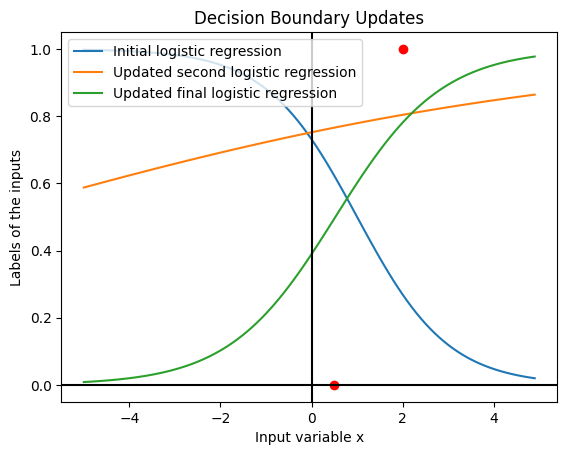

In [5]:
# plot (0.5, 0) and (2, 1) and decision bounary f(1/1+e^(1-x))); on the plot, add x-axis for y=0 and y-axis for x=0

import matplotlib.pyplot as plt

# plot sigmoid of y = w0 + w1*x at given x1 and x2
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def plot_sigmoid(w0, w1, leg):
  x = np.arange(-5, 5, 0.1)
  z = w0 + w1 * x
  phi_z = sigmoid(z)
  plt.plot(x, phi_z, label=leg)

def plot_point(x, y):
  plt.scatter(x, y, color='red')

def plot_axis():
  plt.axhline(y=0, color='black')
  plt.axvline(x=0, color='black')

plot_point(0.5, 0)
plot_point(2, 1)

# 1-x
plot_sigmoid(1, -1, 'Initial logistic regression')
# 1.1086+0.1510x
plot_sigmoid(1.1086, 0.1510, 'Updated second logistic regression')
# -0.45+0.86x
plot_sigmoid(-0.45, 0.86, 'Updated final logistic regression')


plot_axis()

plt.legend(loc=2)

plt.xlabel("Input variable x")
plt.ylabel("Labels of the inputs")

plt.title("Decision Boundary Updates")

plt.show()


# Retrieval Practice

## Converting an Adaline implementation into an algorithm for logistic regression.
Simply,
- Substitute the cost function in our Adaline implementation with the new cost function.
- Swap the linear activation function with the sigmoid activation.

In [6]:
class LogisticRegressionGD(object):
    """Logistic Regression Classifier using gradient descent.

    Parameters
    ------------
    eta : float
      Learning rate (between 0.0 and 1.0)
    n_iter : int
      Passes over the training dataset.
    random_state : int
      Random number generator seed for random weight
      initialization.


    Attributes
    -----------
    w_ : 1d-array
      Weights after fitting.
    cost_ : list
      Logistic cost function value in each epoch.

    """
    def __init__(self, eta = 0.05, epochs = 100, random_state = 1):
        self.eta = eta
        self.epochs = epochs
        self.random_state = random_state

    # w_0 is the bias
    def net_input(self, X):
        """Calculate net input"""

        return np.dot(X, self.w_[1:]) + self.w_[0]


    def activation(self, z):
        """Compute logistic sigmoid activation"""
        return 1. / (1. + np.exp(-np.clip(z, -250, 250)))


    def predict(self, X):
        """Return class label after unit step"""

        return np.where(self.net_input(X) >= 0.0, 1, 0)

        # equivalent to:
        # return np.where(self.activation(self.net_input(X)) >= 0.5, 1, 0)


    def fit(self, X, y):
        """ Fit training data.

        Parameters
        ----------
        X : {array-like}, shape = [n_examples, m_features]
          Training vectors, where n_examples is the number of examples and
          m_features is the number of features.
        y : array-like, shape = [n_examples]
          Target values.

        Returns
        -------
        self : object

        """

        # initialization
        rgen = np.random.RandomState(self.random_state)

        self.w_ = rgen.normal(loc = 0.0, scale = 0.01, size = X.shape[1] + 1)

        self.cost_ = []

        # iterate the training examples in each epoch
        for i in range(self.epochs):

            # compute the linear combination
            net_input = self.net_input(X)

            # compute the sigmoid activation
            output = self.activation(net_input)

            # compute the error
            errors = (y - output)

            # updaate the weights
            self.w_[1:] += self.eta * X.T.dot(errors)

            # update the bias
            self.w_[0] += self.eta * errors.sum()

            # note that we compute the logistic `cost` now
            # instead of the sum of squared errors cost

            eps = 1e-15
            output_clipped = np.clip(output, eps, 1 - eps)

            cost = -y.dot(np.log(output_clipped)) \
                - ((1 - y).dot(np.log(1 - output_clipped)))

            # cost = -y.dot(np.log(output)) - ((1 - y).dot(np.log(1 - output)))

            self.cost_.append(cost)

        return self

## Fit the LR Model on Iris data
- Let's consider only Iris-setosa and Iris-versicolor flower (classes 0 and 1 ) and check that our implementation of logistic regression works:

In [7]:
from sklearn import datasets
iris = datasets.load_iris()

In [8]:
X = iris.data[:, [2, 3]]
y = iris.target

print('Class labels:', np.unique(y))

Class labels: [0 1 2]


In [9]:
X.shape

(150, 2)

In [10]:
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt

def plot_decision_regions(X, y, classifier, test_idx=None, resolution=0.02):

    # setup marker generator and color map
    markers = ('s', 'x', 'o', '^', 'v')
    colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
    cmap = ListedColormap(colors[:len(np.unique(y))])

    # plot the decision surface
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
                           np.arange(x2_min, x2_max, resolution))
    Z = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    Z = Z.reshape(xx1.shape)
    plt.contourf(xx1, xx2, Z, alpha=0.3, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())

    for idx, cl in enumerate(np.unique(y)):
        if markers[idx] == 'x':
            # unfilled marker → no edgecolor
            plt.scatter(x=X[y == cl, 0],
                        y=X[y == cl, 1],
                        alpha=0.8,
                        color=colors[idx],
                        marker=markers[idx],
                        label=cl,
                        linewidths=1.5)
        else:
            # filled markers → edgecolor works
            plt.scatter(x=X[y == cl, 0],
                        y=X[y == cl, 1],
                        alpha=0.8,
                        color=colors[idx],
                        marker=markers[idx],
                        label=cl,
                        edgecolor='black')

    # highlight test examples
    if test_idx is not None:
        X_test, y_test = X[test_idx, :], y[test_idx]

        plt.scatter(X_test[:, 0],
                    X_test[:, 1],
                    facecolors='none',
                    edgecolors='black',
                    alpha=1.0,
                    linewidths=1,
                    marker='o',
                    s=100,
                    label='test set')

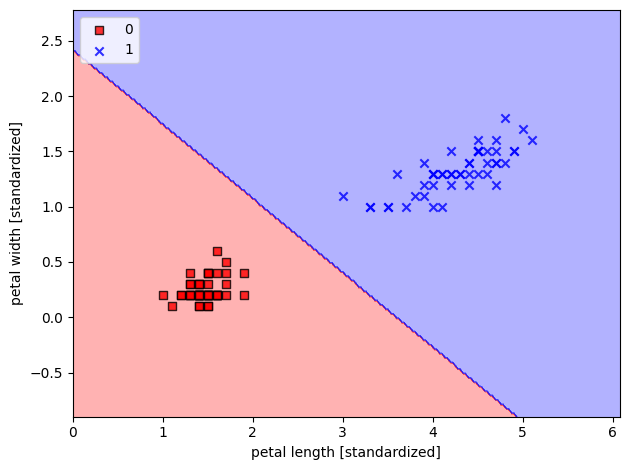

In [11]:
X_01_subset = X[(y == 0) | (y == 1)]
y_01_subset = y[(y == 0) | (y == 1)]

lrgd = LogisticRegressionGD(eta=0.05, epochs=1000, random_state=1)
lrgd.fit(X_01_subset,
         y_01_subset)

plot_decision_regions(X=X_01_subset,
                      y=y_01_subset,
                      classifier=lrgd)

plt.xlabel('petal length [standardized]')
plt.ylabel('petal width [standardized]')
plt.legend(loc='upper left')

plt.tight_layout()
#plt.savefig('images/03_05.png', dpi=300)
plt.show()

# Introduction to Scikit Learn

# The five main steps for training a supervised machine learning algorithm (Your final project should have these components too):
- Selecting features and collecting labeled training examples.
- Choosing a performance metric.
- Choosing a classifier and optimization algorithm.
- Evaluating the performance of the model.
- Tuning the algorithm.

# First steps with scikit-learn
- The scikit-learn API combines a user-friendly and consistent interface with a highly optimized implementation of several classification algorithms.
- It offers many convenient functions to preprocess data and to fine-tune and evaluate our models.
- To get started with the scikit-learn
library, we will train a logistic regression model similar to the one that we implemented before.
- We will use the already familiar Iris dataset that is already available via scikit-learn.

## Load the Iris Dataset
Loading the Iris dataset from scikit-learn. Here, the third column represents the petal length, and the fourth column the petal width of the flower examples. The classes are already converted to integer labels where `0=Iris-Setosa`, `1=Iris-Versicolor`, `2=Iris-Virginica`.

In [12]:
from sklearn import datasets

iris = datasets.load_iris()

In [13]:
iris.data.shape, iris.feature_names

((150, 4),
 ['sepal length (cm)',
  'sepal width (cm)',
  'petal length (cm)',
  'petal width (cm)'])

In [14]:
X = iris.data[:, [2, 3]]
y = iris.target

print('Class labels:', np.unique(y))

Class labels: [0 1 2]


In [15]:
X.shape

(150, 2)

## Split data into 70% training and 30% test data

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1, stratify=y)

In [17]:
print('Labels count in y:', np.bincount(y))
print('Labels count in y_train:', np.bincount(y_train))
print('Labels count in y_test:', np.bincount(y_test))

Labels count in y: [50 50 50]
Labels count in y_train: [35 35 35]
Labels count in y_test: [15 15 15]


## Standardize the features

In [18]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
sc.fit(X_train)
X_train_std = sc.transform(X_train)
X_test_std = sc.transform(X_test)

## Train a Logistic Regression model via scikit-learn

In [19]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(random_state=123)
lr.fit(X_train_std, y_train)

LogisticRegression(random_state=123)

In [20]:
y_pred = lr.predict(X_test_std)
print('Misclassified examples: %d' % (y_test != y_pred).sum())

Misclassified examples: 1


We can calculate the classification accuracy of the logistic regression model on the testdataset as follows:

In [21]:
from sklearn.metrics import accuracy_score

print('Accuracy: %.3f' % accuracy_score(y_test, y_pred))

Accuracy: 0.978


Alternatively, each classifier in scikit-learn has a score
method, which computes a classifier's prediction accuracy by combining the predict call with accuracy_score, as shown here:

In [22]:
print('Accuracy: %.3f' % lr.score(X_test_std, y_test))

Accuracy: 0.978


## Visualization

In [23]:
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt

def plot_decision_regions(X, y, classifier, test_idx=None, resolution=0.02):

    # setup marker generator and color map
    markers = ('s', 'x', 'o', '^', 'v')
    colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
    cmap = ListedColormap(colors[:len(np.unique(y))])

    # plot the decision surface
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
                           np.arange(x2_min, x2_max, resolution))
    Z = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    Z = Z.reshape(xx1.shape)
    plt.contourf(xx1, xx2, Z, alpha=0.3, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())

    for idx, cl in enumerate(np.unique(y)):
        if markers[idx] == 'x':
            # unfilled marker → no edgecolor
            plt.scatter(x=X[y == cl, 0],
                        y=X[y == cl, 1],
                        alpha=0.8,
                        color=colors[idx],
                        marker=markers[idx],
                        label=cl,
                        linewidths=1.5)
        else:
            # filled markers → edgecolor works
            plt.scatter(x=X[y == cl, 0],
                        y=X[y == cl, 1],
                        alpha=0.8,
                        color=colors[idx],
                        marker=markers[idx],
                        label=cl,
                        edgecolor='black')

    # highlight test examples
    if test_idx is not None:
        X_test, y_test = X[test_idx, :], y[test_idx]

        plt.scatter(X_test[:, 0],
                    X_test[:, 1],
                    facecolors='none',
                    edgecolors='black',
                    alpha=1.0,
                    linewidths=1,
                    marker='o',
                    s=100,
                    label='test set')

## Plot a logistic regression model using the standardized training data:

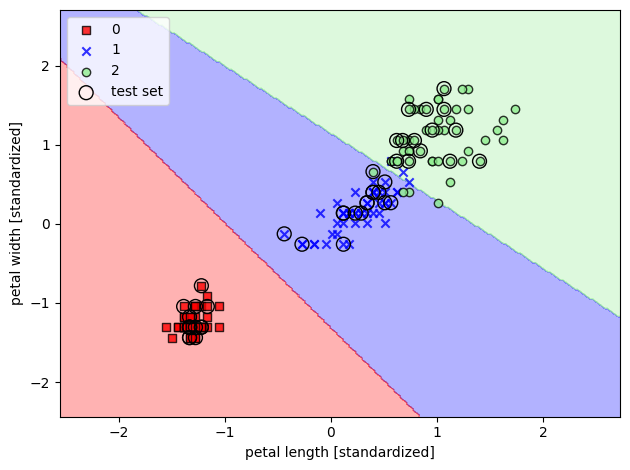

In [24]:
X_combined_std = np.vstack((X_train_std, X_test_std))
y_combined = np.hstack((y_train, y_test))

plot_decision_regions(X=X_combined_std, y=y_combined,
                      classifier=lr, test_idx=range(105, 150))
plt.xlabel('petal length [standardized]')
plt.ylabel('petal width [standardized]')
plt.legend(loc='upper left')

plt.tight_layout()
#plt.savefig('images/03_01.png', dpi=300)
plt.show()

# Retrieval Practice